In [93]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots



In [94]:
output_dir = '/home/slim/dpo-rhlf-paraphrase-types/out/plots'

textwidth2 = 3.08102 #twocolumn
textwidth1 = 6.30045 #onecolumn
aspect_ratio = (5 ** 0.5 - 1) / 2 # golden ratio
width1 = textwidth1
height1 = width1 * aspect_ratio
width2 = textwidth2
height2 = width2 * aspect_ratio
textwidthcm=15.99773 #onecolumn
textwidthcm=7.82315 #twocolumn
textheightcm=textwidthcm / aspect_ratio

# Results
## Effectiveness of DPO and RHLF in Paraphrase Generation

In [95]:
# Load the new JSON data
file_path_apt = '/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-15-07-48-34036765.json'

# Read and parse the JSON file
with open(file_path_apt, 'r') as file:
    data_apt = json.load(file)

# Extract relevant information for APT (kind and count of "Yes" for APT)
apt_accuracies = {
    "etpc_model": 0,
    "base_model": 0,
    "dpo_model": 0
}
apt_counts = {
    "etpc_model": 0,
    "base_model": 0,
    "dpo_model": 0
}

# Loop through the data and gather counts for APT being "Yes"
for item in data_apt:
    if 'APT' in item and 'Kind' in item:
        model = item['Kind']
        if model in apt_accuracies:
            if item['APT'] == 'Yes':
                apt_accuracies[model] += 1
            apt_counts[model] += 1

# Calculate the percentage of APT "Yes" for each model
apt_percentages = {
    model: (apt_accuracies[model] / apt_counts[model] * 100) if apt_counts[model] > 0 else 0
    for model in apt_accuracies
}

apt_percentages


{'etpc_model': 11.827956989247312,
 'base_model': 12.376237623762377,
 'dpo_model': 35.26315789473684}

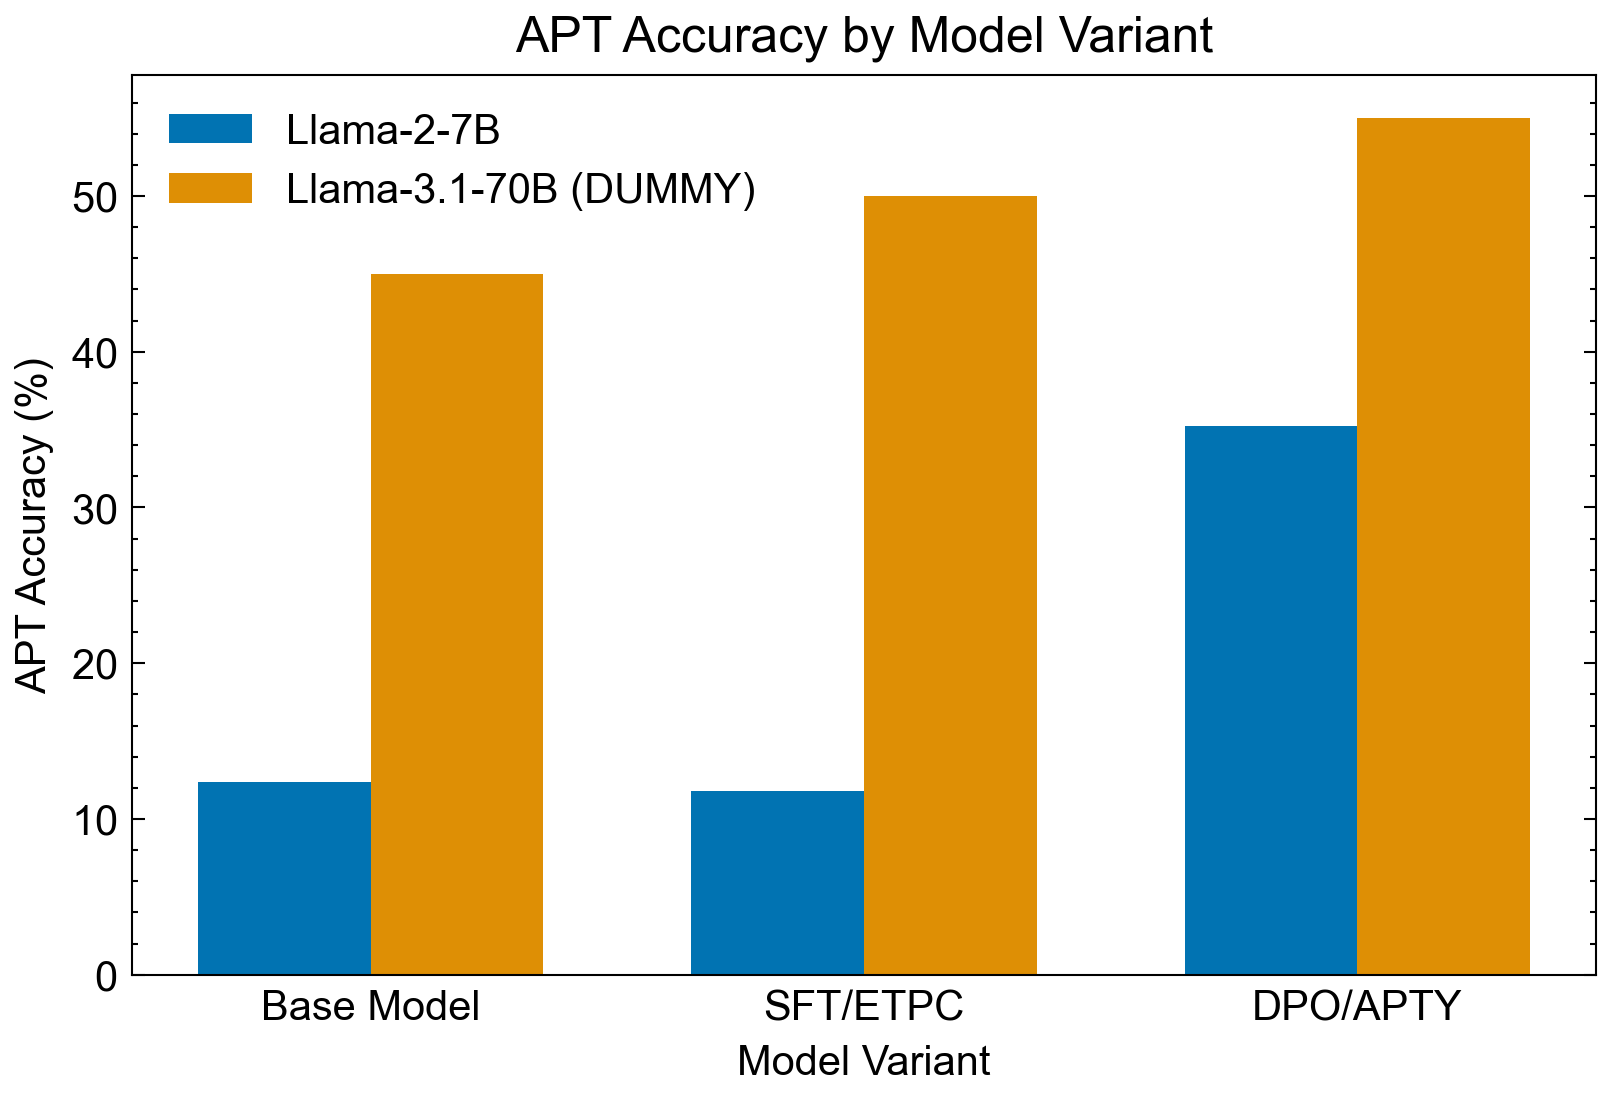

In [96]:
# Data for the grouped bar chart
group_labels = ['Base Model', 'SFT/ETPC', 'DPO/APTY']
llama2_accuracies = [
    apt_percentages["base_model"],
    apt_percentages["etpc_model"],
    apt_percentages["dpo_model"],
]
llama3_accuracies = [
    45.0,
    50,
    55
]

# Define positions for groups
bar_width = 0.35
index = np.arange(len(group_labels))

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.bar(index, llama2_accuracies, bar_width, label='Llama-2-7B')
plt.bar(index + bar_width, llama3_accuracies, bar_width, label='Llama-3.1-70B (DUMMY)')

# Add labels and title with a more formal style
plt.xlabel('Model Variant', fontsize=10)
plt.ylabel('APT Accuracy (%)', fontsize=10)
plt.title('APT Accuracy by Model Variant', fontsize=12)

# Add group labels to x-axis
plt.xticks(index + bar_width / 2, group_labels, fontsize=10)

# Add a legend with a formal appearance
plt.legend(fontsize=10)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis
#ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis

output_path = os.path.join(output_dir, "apt_accuracies.pdf")
plt.savefig(output_path, dpi=300)

# Display the updated plot
plt.show()

## Incorporating Human-Ranked Data for Improved Paraphrase Generation

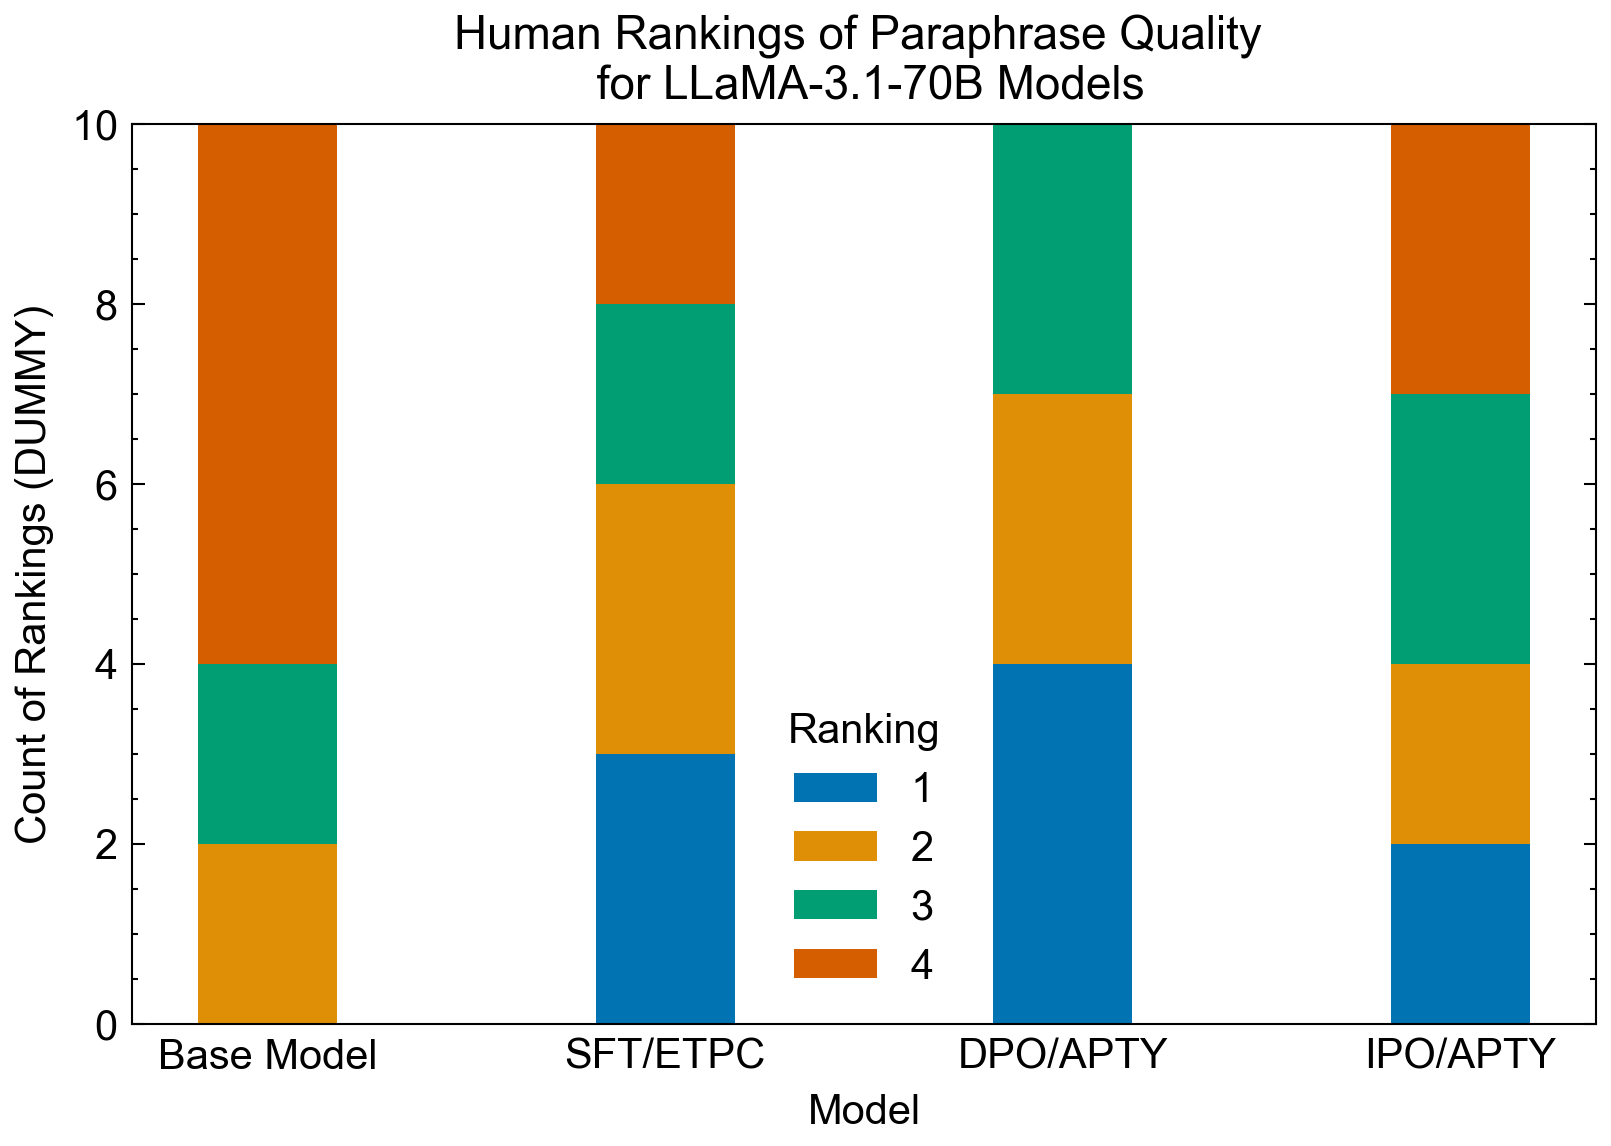

In [97]:
# Adding the base model rankings to the dummy data
data_with_base = {
    "Base Model": [4, 4, 4, 2, 4, 4, 3, 4, 2, 3],
    "SFT/ETPC": [1, 2, 3, 1, 2, 3, 4, 2, 1, 4],
    "DPO/APTY": [2, 1, 1, 3, 3, 2, 2, 1, 3, 1],
    "IPO/APTY": [3, 3, 2, 4, 1, 4, 1, 3, 4, 2]
}

# Convert updated data to a DataFrame
df_with_base = pd.DataFrame(data_with_base)

# Count how often each model got each ranking (1 to 4)
rank_counts_with_base = df_with_base.apply(lambda col: col.value_counts()).fillna(0).astype(int)

# Transpose for better plotting (stacked bar chart)
rank_counts_with_base = rank_counts_with_base.transpose()

# Plot the stacked bar chart with the base model
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

index = range(len(rank_counts_with_base))

for i, col in enumerate(rank_counts_with_base.columns):
    ax.bar(index, rank_counts_with_base[col], bar_width, bottom=rank_counts_with_base.iloc[:, :i].sum(axis=1))

# Set x-tick labels to the model names
ax.set_xticks(index)
ax.set_xticklabels(rank_counts_with_base.index, fontsize=10)


# Add labels and title
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('Count of Rankings (DUMMY)', fontsize=10)
ax.set_title('Human Rankings of Paraphrase Quality \n for LLaMA-3.1-70B Models', fontsize=11)


# Add legend
ax.legend(rank_counts_with_base.columns, title="Ranking", frameon=False, fontsize=10)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

## Broader NLP Task Improvements with Human-Ranked Data

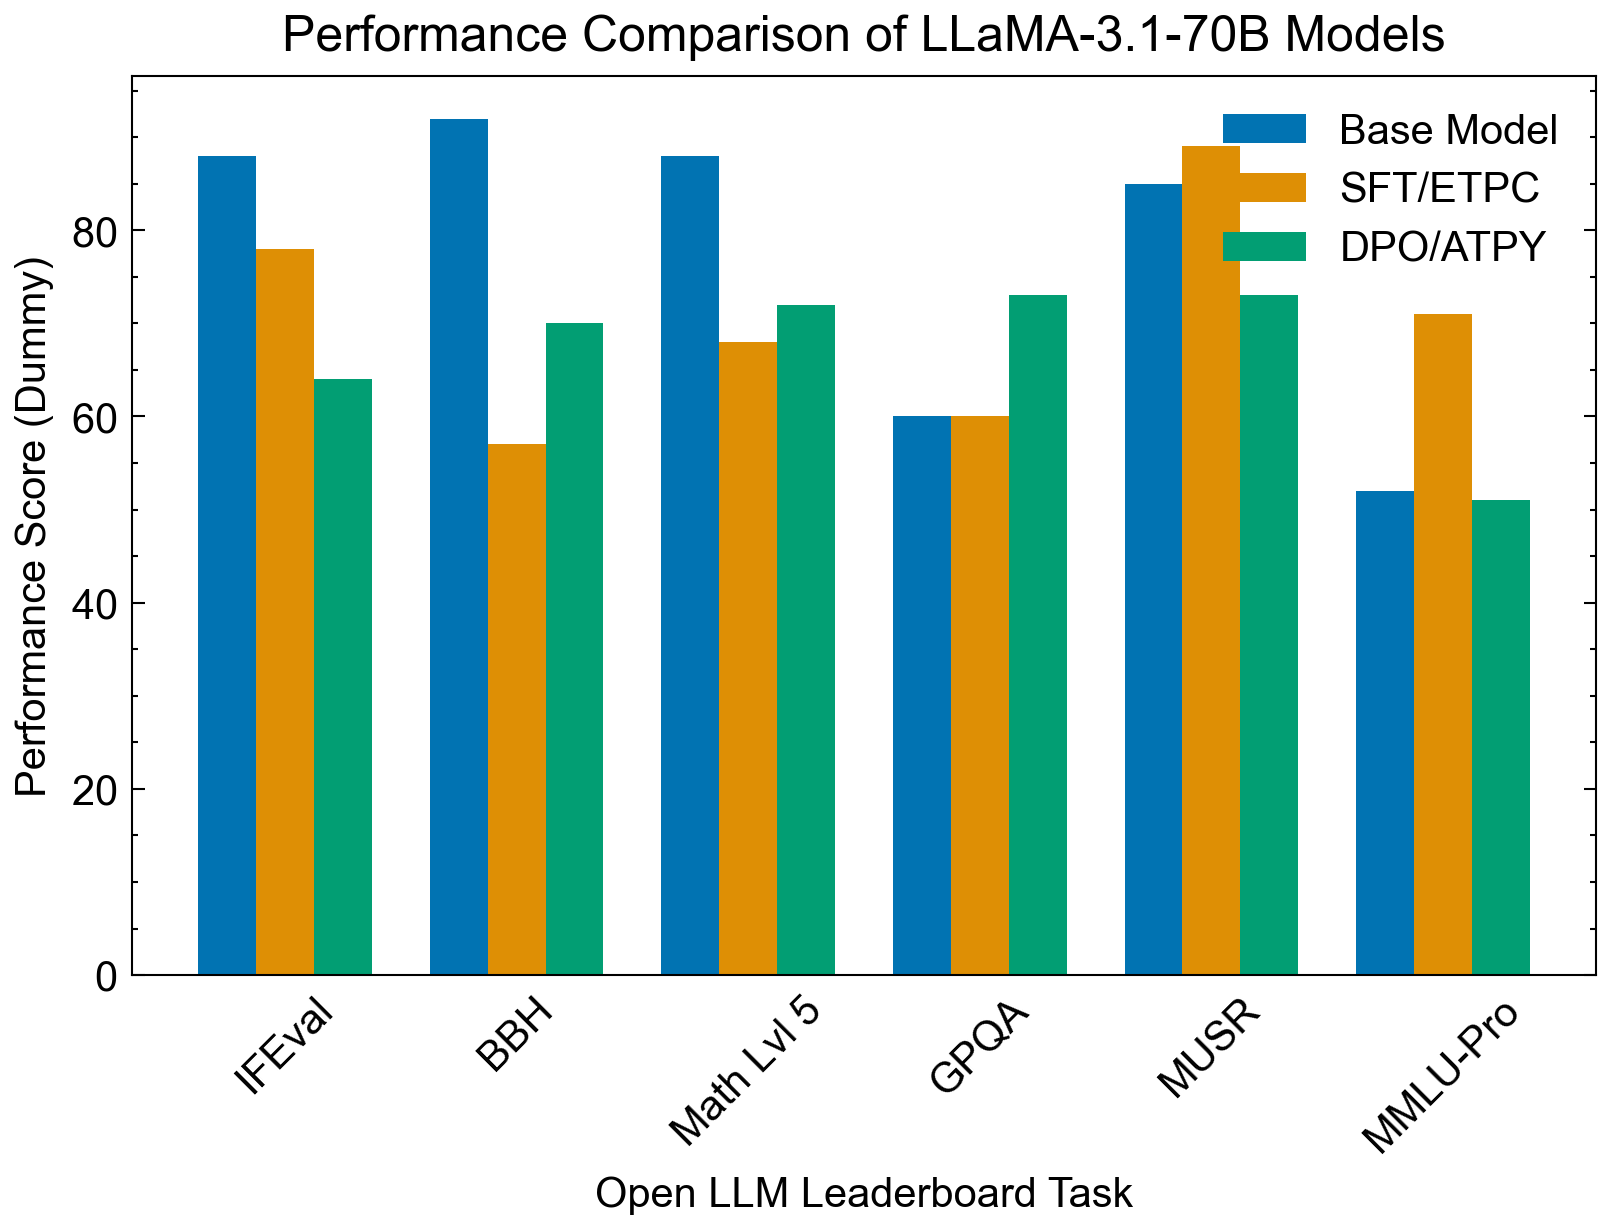

In [98]:
# Define tasks and models
tasks = ['IFEval', 'BBH', 'Math Lvl 5', 'GPQA', 'MUSR', 'MMLU-Pro']
models = ['Base Model', 'SFT/ETPC', 'DPO/ATPY']

# Create dummy scores for each task and model
np.random.seed(42)
scores = np.random.randint(50, 100, size=(len(tasks), len(models)))

# Create a grouped bar chart
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
bar_width = 0.25
index = np.arange(len(tasks))

# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(index + i * bar_width, scores[:, i], bar_width, label=model)

# Set labels, title, and ticks
ax.set_xlabel('Open LLM Leaderboard Task', fontsize=10)
ax.set_ylabel('Performance Score (Dummy)', fontsize=10)
ax.set_title('Performance Comparison of LLaMA-3.1-70B Models', fontsize=12)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(tasks)

# Add legend
ax.legend(fontsize=10)

# Rotate task labels for readability
plt.xticks(rotation=45)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

output_path = os.path.join(output_dir, "llmboard.pdf")
plt.savefig(output_path, dpi=300)

plt.show()


## Correlation Between Automatic Metrics and Human Judgment

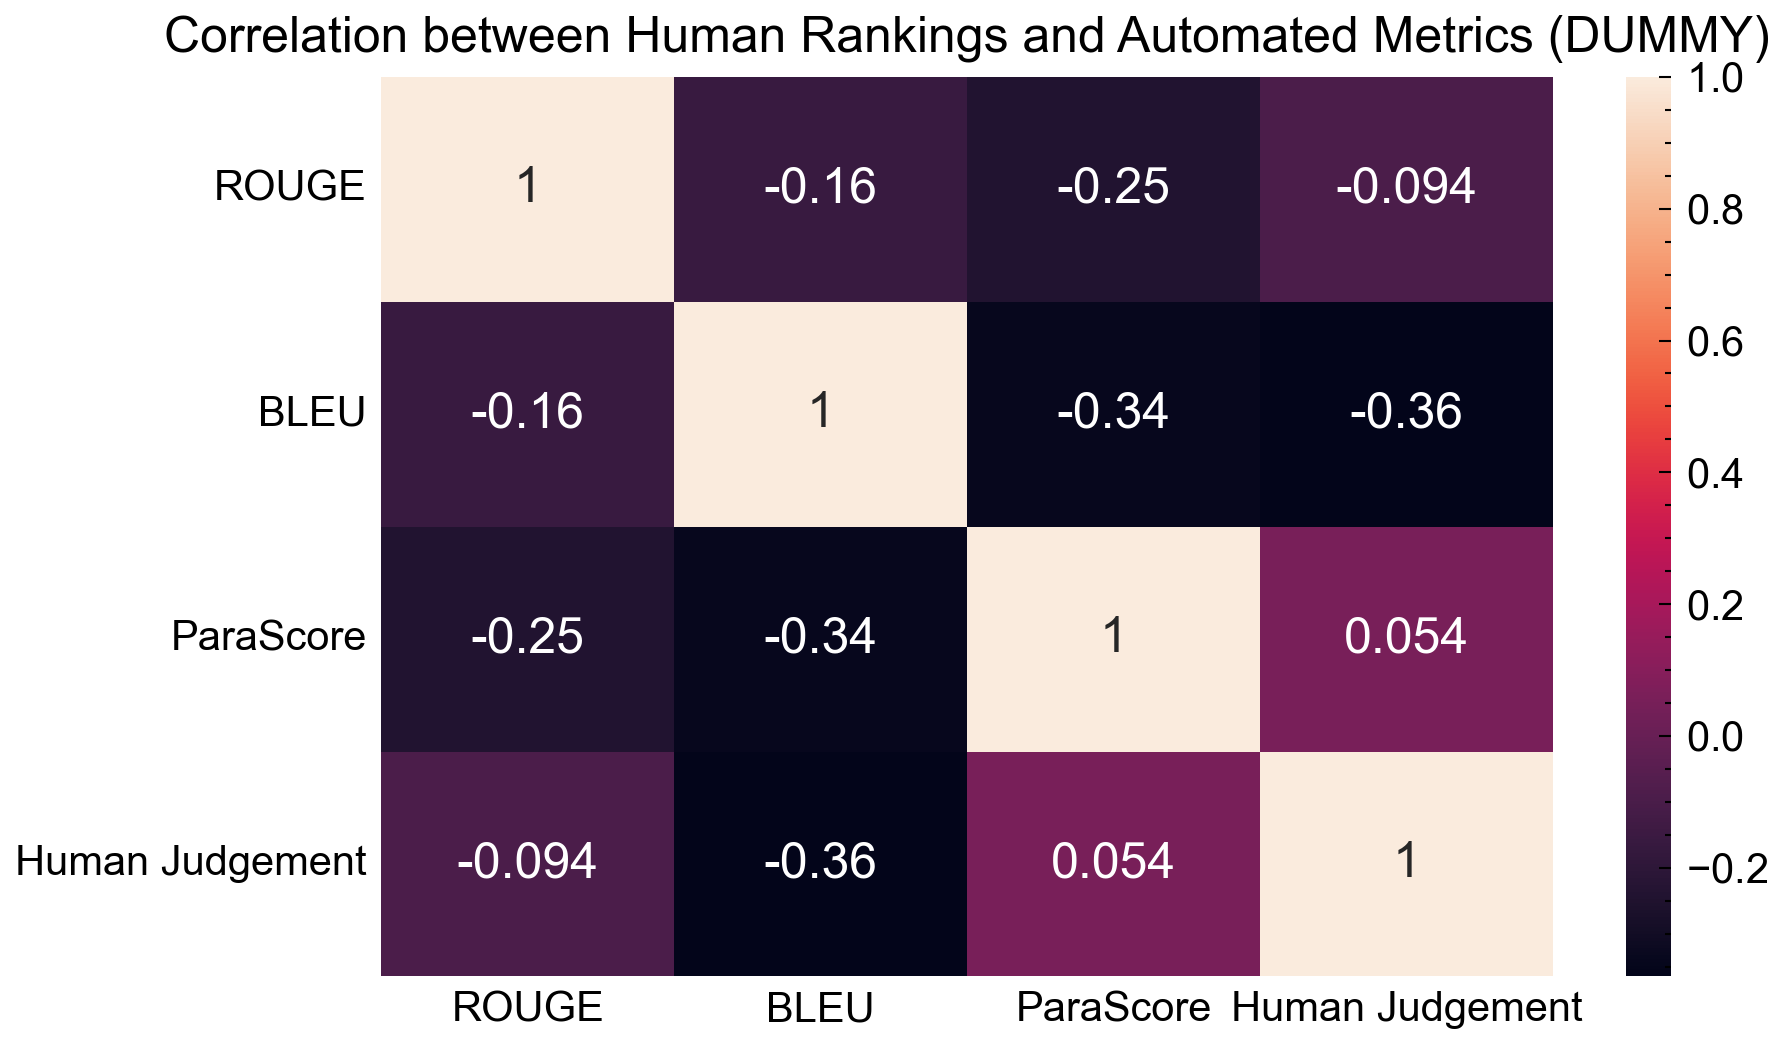

In [99]:
# Generate dummy scores for human rankings and automated metrics (ROUGE, BLEU, ParaScore)
rouge_scores = np.random.uniform(0.4, 0.9, size=10)  # ROUGE scores
bleu_scores = np.random.uniform(0.3, 0.8, size=10)  # BLEU scores
parascale_scores = np.random.uniform(0.5, 0.95, size=10)  # ParaScore
human_scores = np.random.uniform(0.5, 0.95, size=10) 

# Create a DataFrame for correlation matrix
data = {
    'ROUGE': rouge_scores,
    'BLEU': bleu_scores,
    'ParaScore': parascale_scores,
    'Human Judgement': human_scores
}
df = pd.DataFrame(data)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set figure size according to the provided description


# Create a heatmap for the correlation matrix
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
sns.heatmap(corr_matrix, annot=True, ax=ax, annot_kws={"fontsize": 12})

# Add title
plt.title('Correlation between Human Rankings and Automated Metrics (DUMMY)', fontsize=12)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis

# Save the correlation matrix as a PDF
output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()


## New metric

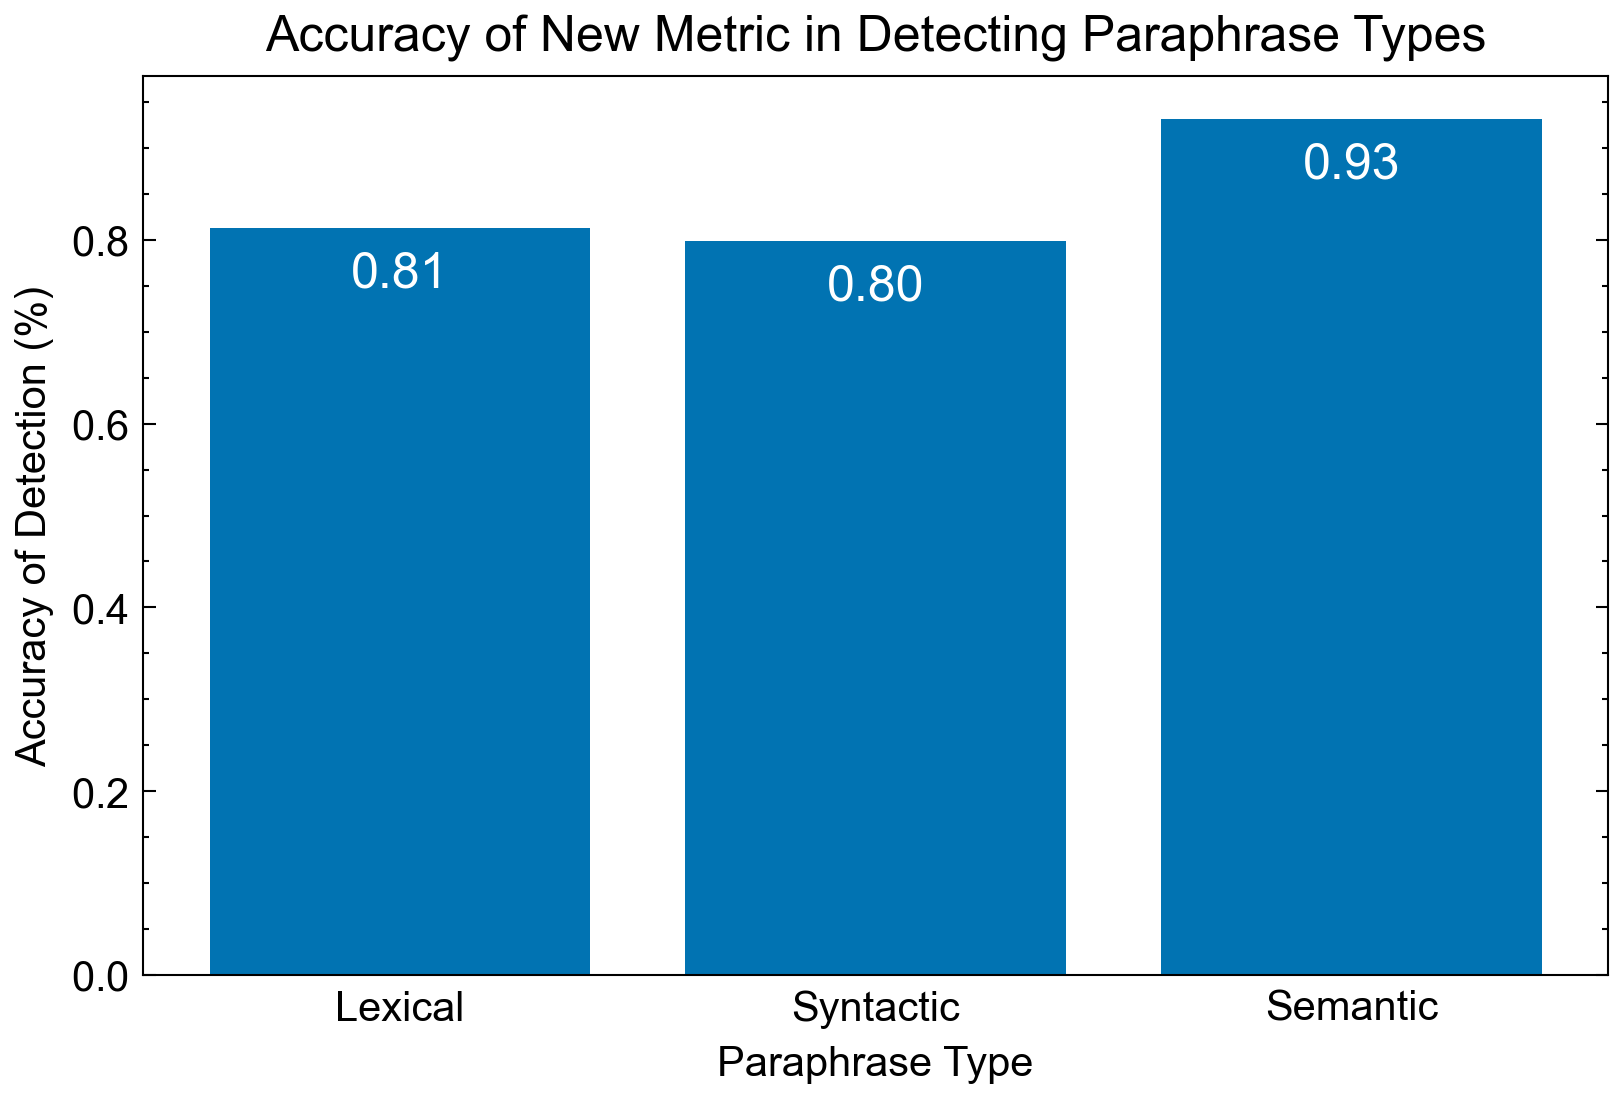

In [100]:

# Create dummy data for the accuracy of the new metric at detecting paraphrase types
paraphrase_types = ['Lexical', 'Syntactic', 'Semantic']
accuracy_scores = np.random.uniform(0.7, 0.95, size=len(paraphrase_types))  # Dummy accuracy values

# Create a DataFrame for the data
df_accuracy = pd.DataFrame({
    'Paraphrase Type': paraphrase_types,
    'Accuracy': accuracy_scores
})

# Set figure size

fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Create a bar chart to show the accuracy for each paraphrase type
ax.bar(df_accuracy['Paraphrase Type'], df_accuracy['Accuracy'])

# Add labels and title
ax.set_xlabel('Paraphrase Type', fontsize=10)
ax.set_ylabel('Accuracy of Detection (%)', fontsize=10)
ax.set_title('Accuracy of New Metric in Detecting Paraphrase Types', fontsize=12)

# Add accuracy values on top of each bar
for i, v in enumerate(accuracy_scores):
    ax.text(i, v - 0.05, f"{v:.2f}", ha='center', va="center",color="white", fontsize=12)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

# Save as a PDF
output_path = os.path.join(output_dir, "newaccuracy.pdf")
plt.savefig(output_path, dpi=300)

# Show plot
plt.show()


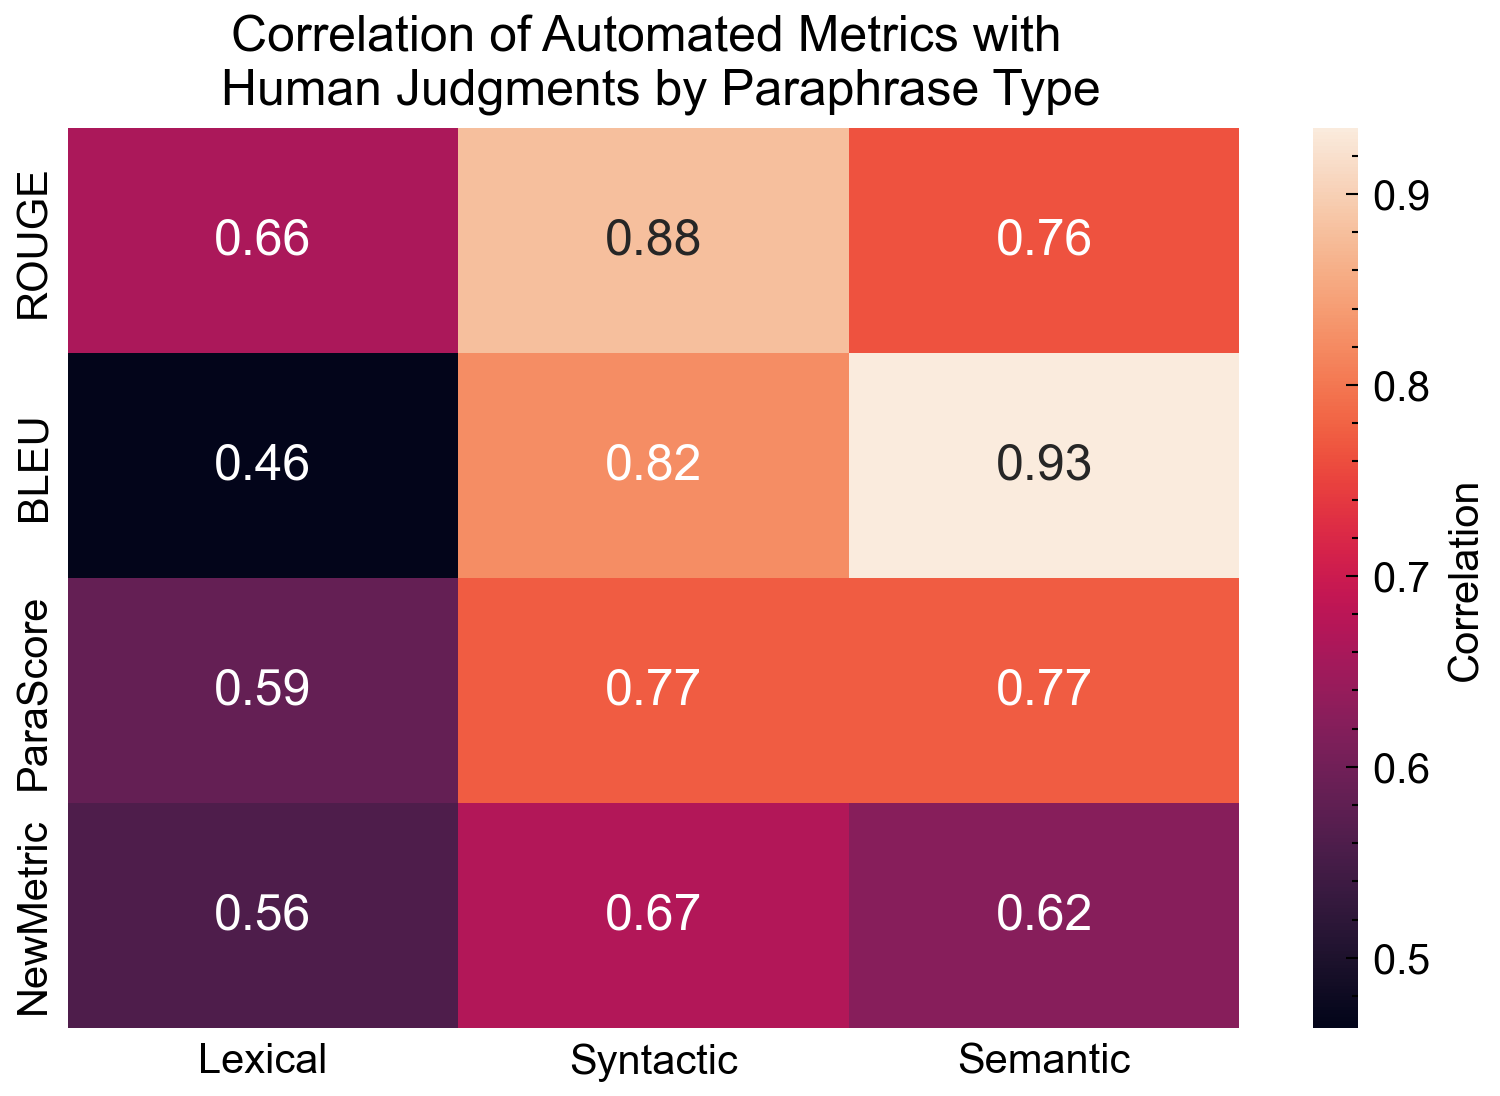

In [101]:
# Dummy data creation
paraphrase_types = ['Lexical', 'Syntactic', 'Semantic']
metrics = ['ROUGE', 'BLEU', 'ParaScore', 'NewMetric']

# Generate dummy correlation scores for each metric and paraphrase type
correlation_scores = {
    'Lexical': np.random.uniform(0.3, 0.8, size=4),
    'Syntactic': np.random.uniform(0.4, 0.9, size=4),
    'Semantic': np.random.uniform(0.5, 0.95, size=4)
}
# Create the DataFrame for heatmap
heatmap_data = pd.DataFrame(correlation_scores, index=metrics)

# Plot heatmap

fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

sns.heatmap(heatmap_data, annot=True, cbar_kws={'label': 'Correlation'}, annot_kws={"fontsize": 12})

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis


# Add title
plt.title('Correlation of Automated Metrics with \n Human Judgments by Paraphrase Type', fontsize=12)

# Save as a PDF
output_path = os.path.join(output_dir, "newcorrelation.pdf")
plt.savefig(output_path, dpi=300)

# Show plot
plt.show()
